# DENTEX Object Detection — Model Comparison and Selection

Architecture screening has produced persisted experiments for the YOLO26n baseline and E1–E4 detector configurations. This notebook does not train or resume models. It reads the stored validation evidence, verifies artifact eligibility, compares completed experiments, records a provisional refinement candidate, and hands that decision to [`06_fcos_refinement.ipynb`](06_fcos_refinement.ipynb).

Selection is validation-driven. Test performance is not used here for ranking, architecture selection, or refinement decisions.

## 1. Comparison Methodology

Separating comparison from training prevents transient kernel state or a partially completed run from influencing model selection. The workflow is:

$$
\text{persisted E0--E4 artifacts}
\rightarrow \text{health and provenance checks}
\rightarrow \text{validation comparison}
\rightarrow \text{candidate selection}
\rightarrow \text{FCOS refinement}.
$$

The candidate set contains E0 YOLO26n, E1 SSD300 VGG16, E2 FCOS ResNet50 FPN, E3 Faster R-CNN ResNet50 FPN, and E4 DETR ResNet50. Only experiments classified as `COMPLETED` enter numerical comparison. `NOT_STARTED`, `INCOMPLETE`, and `MISSING_ARTIFACTS` states remain visible but ineligible, preventing absent, partial, or structurally damaged runs from contaminating the decision.

### Read-Only Initialization

The initialization fixes seed 42, resolves project paths, and declares the candidate registry. It exposes only validation data paths because this notebook neither trains models nor evaluates the test subset.

In [33]:
from dataclasses import asdict, dataclass
from pathlib import Path
import gc
import hashlib
import json
import random
import time

import matplotlib.pyplot as plt
import mlflow
import numpy as np
import pandas as pd
import seaborn as sns
import torch
from IPython.display import display
from PIL import Image, ImageDraw
from torchvision.transforms import functional as TF

SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
sns.set_theme(style="whitegrid")


In [34]:
@dataclass(frozen=True)
class Paths:
    root: Path
    canonical: Path
    yolo: Path
    baseline: Path
    experiments: Path
    modeling: Path
    tracking_db: Path

def resolve_paths() -> Paths:
    root = Path.cwd().resolve()
    if not (root / "data" / "processed" / "dentex_diagnosis").is_dir():
        root = root.parent
    modeling = root / "artifacts" / "modeling"
    return Paths(root, root / "data" / "processed" / "dentex_diagnosis", root / "data" / "model_ready" / "dentex_yolo", root / "artifacts" / "baseline" / "yolo26n_640_seed42", root / "artifacts" / "experiments", modeling, modeling / "mlflow.db")

PATHS = resolve_paths()
CANONICAL_CLASS_NAMES = {0: "Impacted", 1: "Caries", 2: "Periapical Lesion", 3: "Deep Caries"}
VAL_JSON = PATHS.canonical / "annotations" / "val.json"
VAL_IMAGES = PATHS.canonical / "images" / "val"
for required in (VAL_JSON, VAL_IMAGES):
    if not required.exists(): raise FileNotFoundError(required)
MLFLOW_EXPERIMENT = "dentex-object-detection-modeling"
mlflow.set_tracking_uri(f"sqlite:///{PATHS.tracking_db.resolve().as_posix()}")
display(pd.Series({**{k: str(v) for k, v in asdict(PATHS).items()}, "seed": SEED}, name="value").to_frame())


,value
root,C:\Users\Eclipse\PycharmProjects\Dental-Xray-P...
canonical,C:\Users\Eclipse\PycharmProjects\Dental-Xray-P...
yolo,C:\Users\Eclipse\PycharmProjects\Dental-Xray-P...
baseline,C:\Users\Eclipse\PycharmProjects\Dental-Xray-P...
experiments,C:\Users\Eclipse\PycharmProjects\Dental-Xray-P...
modeling,C:\Users\Eclipse\PycharmProjects\Dental-Xray-P...
tracking_db,C:\Users\Eclipse\PycharmProjects\Dental-Xray-P...
seed,42


In [35]:
@dataclass(frozen=True)
class Candidate:
    experiment_id: str
    model_name: str
    family: str
    architecture: str
    artifact_name: str
    image_size: int

CANDIDATES = [
    Candidate("E0_yolo26n_640_baseline", "YOLO26n", "yolo", "one-stage", "../baseline/yolo26n_640_seed42", 640),
    Candidate("E1_ssd300", "SSD300 VGG16", "ssd", "one-stage", "ssd300_seed42", 300),
    Candidate("E2_fcos_640", "FCOS ResNet50 FPN", "fcos", "one-stage anchor-free", "fcos_seed42", 640),
    Candidate("E3_fasterrcnn_640", "Faster R-CNN ResNet50 FPN", "faster_rcnn", "two-stage", "fasterrcnn_seed42", 640),
    Candidate("E4_detr_640", "DETR ResNet50", "detr", "transformer", "detr_seed42", 640),
]

def candidate_dir(item: Candidate) -> Path:
    return PATHS.baseline if item.family == "yolo" else PATHS.experiments / item.artifact_name

def artifact_paths(item: Candidate) -> dict[str, Path]:
    run_dir = candidate_dir(item)
    if item.family == "yolo":
        return {"run_dir": run_dir, "history": run_dir / "results.csv", "metrics": PATHS.root / "artifacts" / "baseline" / "metrics" / "yolo26n_640_seed42_metrics.json", "best": run_dir / "weights" / "best.pt", "last": run_dir / "weights" / "last.pt"}
    if item.family == "detr":
        return {"run_dir": run_dir, "history": run_dir / "history.csv", "metrics": run_dir / "metrics.json", "best": run_dir / "best", "last": run_dir / "last"}
    return {"run_dir": run_dir, "history": run_dir / "history.csv", "metrics": run_dir / "metrics.json", "best": run_dir / "best.pth", "last": run_dir / "last.pth"}

def read_json(path: Path) -> dict:
    try:
        return json.loads(path.read_text(encoding="utf-8")) if path.is_file() else {}
    except (OSError, json.JSONDecodeError):
        return {}


## 2. Persisted Metrics as Primary Evidence

Each experiment is represented by its canonical run directory, history file, metrics JSON, and best checkpoint. These persisted files are the primary evidence because they survive kernel restarts and identify the historical experiment that actually ran. MLflow provides auxiliary indexing and consistency checks, but it does not replace the canonical files.

Artifact discovery assigns health from the required files. A completed status means that a best checkpoint, readable history path, and metrics file exist; it does not by itself prove that every historical field was produced at the same epoch. More detailed provenance limitations are handled explicitly below.

In [36]:
def discover_artifacts(candidates=CANDIDATES) -> pd.DataFrame:
    rows = []
    for item in candidates:
        paths = artifact_paths(item)
        present = {name: path.exists() for name, path in paths.items() if name != "run_dir"}
        if not paths["run_dir"].exists(): state = "NOT_STARTED"
        elif present.get("best") and present.get("history") and present.get("metrics"): state = "COMPLETED"
        elif any(present.values()): state = "MISSING_ARTIFACTS"
        else: state = "INCOMPLETE"
        metrics = read_json(paths["metrics"])
        rows.append({"experiment_id": item.experiment_id, "model": item.model_name, "artifact_state": state, "history": "OK" if present.get("history") else "MISSING", "metrics": "OK" if present.get("metrics") else "MISSING", "best_checkpoint": "OK" if present.get("best") else "MISSING", "mlflow_run": metrics.get("mlflow_run_id") or "unknown"})
    return pd.DataFrame(rows)

artifact_inventory = discover_artifacts()
display(artifact_inventory)


,experiment_id,model,artifact_state,history,metrics,best_checkpoint,mlflow_run
0,E0_yolo26n_640_baseline,YOLO26n,COMPLETED,OK,OK,OK,unknown
1,E1_ssd300,SSD300 VGG16,COMPLETED,OK,OK,OK,unknown
2,E2_fcos_640,FCOS ResNet50 FPN,COMPLETED,OK,OK,OK,unknown
3,E3_fasterrcnn_640,Faster R-CNN ResNet50 FPN,COMPLETED,OK,OK,OK,unknown
4,E4_detr_640,DETR ResNet50,COMPLETED,OK,OK,OK,unknown


**Observed artifact state.** All five candidates currently satisfy the notebook's `COMPLETED` eligibility rule. Their metrics and checkpoints are therefore available for validation-based comparison. Historical MLflow run IDs embedded in the metrics files are absent, which is reported rather than reconstructed.

In [37]:
def first_value(payload: dict, *keys, default=np.nan):
    for key in keys:
        if key in payload and payload[key] is not None: return payload[key]
    return default

def load_completed_summaries(inventory=artifact_inventory) -> pd.DataFrame:
    rows = []
    completed = set(inventory.loc[inventory.artifact_state.eq("COMPLETED"), "experiment_id"])
    for item in CANDIDATES:
        if item.experiment_id not in completed: continue
        paths = artifact_paths(item); metrics = read_json(paths["metrics"])
        try: history = pd.read_csv(paths["history"])
        except Exception: history = pd.DataFrame()
        best_row = history.iloc[history["mAP50_95"].astype(float).argmax()].to_dict() if "mAP50_95" in history and history["mAP50_95"].notna().any() else {}
        rows.append({
            "experiment_id": item.experiment_id, "model": item.model_name, "architecture": item.architecture, "imgsz": item.image_size,
            "precision": first_value(metrics, "precision", default=best_row.get("precision", np.nan)),
            "recall": first_value(metrics, "recall", default=best_row.get("recall", np.nan)),
            "recall_semantics": "Ultralytics box Recall" if item.family == "yolo" else "TorchMetrics mAR@100",
            "mAP50": first_value(metrics, "mAP50", "mAP@0.5", default=best_row.get("mAP50", best_row.get("metrics/mAP50(B)", np.nan))),
            "mAP50_95": first_value(metrics, "mAP50_95", "best_mAP50_95", "mAP@0.5:0.95", default=best_row.get("mAP50_95", best_row.get("metrics/mAP50-95(B)", np.nan))),
            "best_epoch": first_value(metrics, "best_epoch", default=best_row.get("epoch", np.nan)),
            "training_time_seconds": first_value(metrics, "training_time_seconds", default=float(history["training_time_seconds"].sum()) if "training_time_seconds" in history else np.nan),
            "inference_latency_ms": first_value(metrics, "inference_latency_ms"), "parameter_count": first_value(metrics, "parameter_count"),
            "model_size_mb": first_value(metrics, "model_size_mb"), "small_object_recall": first_value(metrics, "small_object_recall"),
            "best_checkpoint": str(paths["best"]), "mlflow_run_id": metrics.get("mlflow_run_id")
        })
    return pd.DataFrame(rows)

summary = load_completed_summaries()
display(summary.sort_values("mAP50_95", ascending=False, na_position="last") if not summary.empty else summary)


,experiment_id,model,architecture,imgsz,precision,recall,recall_semantics,mAP50,mAP50_95,best_epoch,training_time_seconds,inference_latency_ms,parameter_count,model_size_mb,small_object_recall,best_checkpoint,mlflow_run_id
2,E2_fcos_640,FCOS ResNet50 FPN,one-stage anchor-free,640,NaN,0.645374,TorchMetrics mAR@100,0.443819,0.276385,5,4506.932136,NaN,NaN,NaN,NaN,C:\Users\Eclipse\PycharmProjects\Dental-Xray-P...,None
3,E3_fasterrcnn_640,Faster R-CNN ResNet50 FPN,two-stage,640,NaN,0.475617,TorchMetrics mAR@100,0.472131,0.272988,13,5091.598721,NaN,NaN,NaN,NaN,C:\Users\Eclipse\PycharmProjects\Dental-Xray-P...,None
0,E0_yolo26n_640_baseline,YOLO26n,one-stage,640,0.445384,0.478697,Ultralytics box Recall,0.431174,0.264111,18,NaN,NaN,NaN,NaN,NaN,C:\Users\Eclipse\PycharmProjects\Dental-Xray-P...,None
4,E4_detr_640,DETR ResNet50,transformer,640,NaN,0.372408,TorchMetrics mAR@100,0.307071,0.155492,18,6558.190400,NaN,NaN,NaN,NaN,C:\Users\Eclipse\PycharmProjects\Dental-Xray-P...,None
1,E1_ssd300,SSD300 VGG16,one-stage,300,NaN,0.345681,TorchMetrics mAR@100,0.275024,0.137150,10,2222.490044,NaN,NaN,NaN,NaN,C:\Users\Eclipse\PycharmProjects\Dental-Xray-P...,None


## 3. MLflow Consistency Check

The local `dentex-object-detection-modeling` experiment is queried read-only. Persisted metrics remain authoritative; MLflow is used to expose matching, missing, duplicated, failed, or stale tracking records. Disagreement is not repaired silently.

The current historical store is incomplete: several runs lack `tags.experiment_id`, E1 has duplicate and failed records, E2 and E3 are not consistently indexed by the expected tag, and the visible E4 tracked metric reflects a final state rather than its persisted historical best. These limitations make MLflow unsuitable as the sole source of truth for this comparison.

In [38]:
def mlflow_leaderboard() -> pd.DataFrame:
    experiment = mlflow.get_experiment_by_name(MLFLOW_EXPERIMENT)
    if experiment is None: return pd.DataFrame()
    runs = mlflow.search_runs([experiment.experiment_id], output_format="pandas")
    wanted = ["run_id", "tags.experiment_id", "tags.mlflow.runName", "status", "metrics.precision", "metrics.recall", "metrics.mAP50", "metrics.mAP50_95"]
    return runs[[column for column in wanted if column in runs]].copy()

mlflow_runs = mlflow_leaderboard()
display(mlflow_runs)

if not summary.empty and not mlflow_runs.empty and "tags.experiment_id" in mlflow_runs:
    mlflow_metric = next((c for c in ("metrics.mAP50_95", "metrics.best_mAP50_95") if c in mlflow_runs), None)
    if mlflow_metric:
        check = summary[["experiment_id", "mAP50_95"]].merge(mlflow_runs[["tags.experiment_id", mlflow_metric]], left_on="experiment_id", right_on="tags.experiment_id", how="left")
        check["metric_disagreement"] = check[mlflow_metric].notna() & ~np.isclose(check["mAP50_95"], check[mlflow_metric], equal_nan=True)
        display(check)


,run_id,tags.experiment_id,tags.mlflow.runName,status,metrics.precision,metrics.recall,metrics.mAP50,metrics.mAP50_95
0,5b2630950f384adeb9c68bacc44764bb,NaN,F_final_fcos_tuned,FINISHED,NaN,0.497579,0.470893,0.272229
1,49c6a6be07414242aef060a85f52c182,NaN,E3_freeze_backbone_5ep,FINISHED,NaN,0.516674,0.478051,0.278417
2,e690e2e968844dc98ff48561fd664888,NaN,E2_freeze_backbone_3ep,FINISHED,NaN,0.445611,0.464721,0.245745
3,80ebd29136e143858e2cb1d5d5382b4e,NaN,E1_full_finetune,FINISHED,NaN,0.495779,0.436810,0.260823
4,34654a65efed4906ae1722aa8f50f556,NaN,E1_full_finetune,FAILED,NaN,NaN,NaN,NaN
5,44968934fdf24283ad0c14d3d05dc290,NaN,D5_resnet101_confirm_optional,FINISHED,NaN,0.426734,0.403438,0.209951
6,ba74e2dd1f0949918294548bb887badf,NaN,D4_resnet50_confirm_fixed,FINISHED,NaN,0.522188,0.450589,0.271778
7,1e82c58dcaf94c9982bd1e7ca92e78ef,NaN,D5_top2_confirm,FINISHED,NaN,0.250758,0.240903,0.104419
8,55afb336b2e1414da584d89aed371d25,NaN,D4_top1_confirm,FINISHED,NaN,0.426423,0.270024,0.139779
9,74b8859910454badbea264dd7769b52f,NaN,D3_resnet101_proxy,FINISHED,NaN,0.458860,0.407387,0.220426


,experiment_id,mAP50_95,tags.experiment_id,metrics.mAP50_95,metric_disagreement
0,E0_yolo26n_640_baseline,0.264111,E0_yolo26n_640_baseline,0.264111,False
1,E1_ssd300,0.137150,E1_ssd300,0.000000,True
2,E1_ssd300,0.137150,E1_ssd300,NaN,False
3,E1_ssd300,0.137150,E1_ssd300,NaN,False
4,E2_fcos_640,0.276385,NaN,NaN,False
5,E3_fasterrcnn_640,0.272988,NaN,NaN,False
6,E4_detr_640,0.155492,E4_detr_640,0.106239,True


## 4. Test-Set Boundary

Test performance is not used in this notebook for ranking, architecture selection, or refinement decisions. The broader project inspected aggregate test structure during data analysis, so an absolute claim that test data were never accessed would be inaccurate. The methodological boundary that matters here is that **model selection remains validation-driven** and no test inference or test metric is introduced.

## 5. Aggregate Validation Comparison

Completed experiments are ranked only by the primary metric,

$$
\mathrm{mAP}_{0.5:0.95}.
$$

Recall-like fields are retained for diagnosis with an explicit semantic label: YOLO reports Ultralytics box Recall, whereas E1–E4 report TorchMetrics $\mathrm{mAR}@100$. They are not used as cross-framework tie-breakers. The chart therefore compares only the two aggregate AP measures with compatible intended meaning.

,experiment_id,model,architecture,imgsz,precision,recall,recall_semantics,mAP50,mAP50_95,best_epoch,training_time_seconds,inference_latency_ms,parameter_count,model_size_mb,small_object_recall,best_checkpoint,mlflow_run_id
0,E2_fcos_640,FCOS ResNet50 FPN,one-stage anchor-free,640,NaN,0.645374,TorchMetrics mAR@100,0.443819,0.276385,5,4506.932136,NaN,NaN,NaN,NaN,C:\Users\Eclipse\PycharmProjects\Dental-Xray-P...,None
1,E3_fasterrcnn_640,Faster R-CNN ResNet50 FPN,two-stage,640,NaN,0.475617,TorchMetrics mAR@100,0.472131,0.272988,13,5091.598721,NaN,NaN,NaN,NaN,C:\Users\Eclipse\PycharmProjects\Dental-Xray-P...,None
2,E0_yolo26n_640_baseline,YOLO26n,one-stage,640,0.445384,0.478697,Ultralytics box Recall,0.431174,0.264111,18,NaN,NaN,NaN,NaN,NaN,C:\Users\Eclipse\PycharmProjects\Dental-Xray-P...,None
3,E4_detr_640,DETR ResNet50,transformer,640,NaN,0.372408,TorchMetrics mAR@100,0.307071,0.155492,18,6558.190400,NaN,NaN,NaN,NaN,C:\Users\Eclipse\PycharmProjects\Dental-Xray-P...,None
4,E1_ssd300,SSD300 VGG16,one-stage,300,NaN,0.345681,TorchMetrics mAR@100,0.275024,0.137150,10,2222.490044,NaN,NaN,NaN,NaN,C:\Users\Eclipse\PycharmProjects\Dental-Xray-P...,None


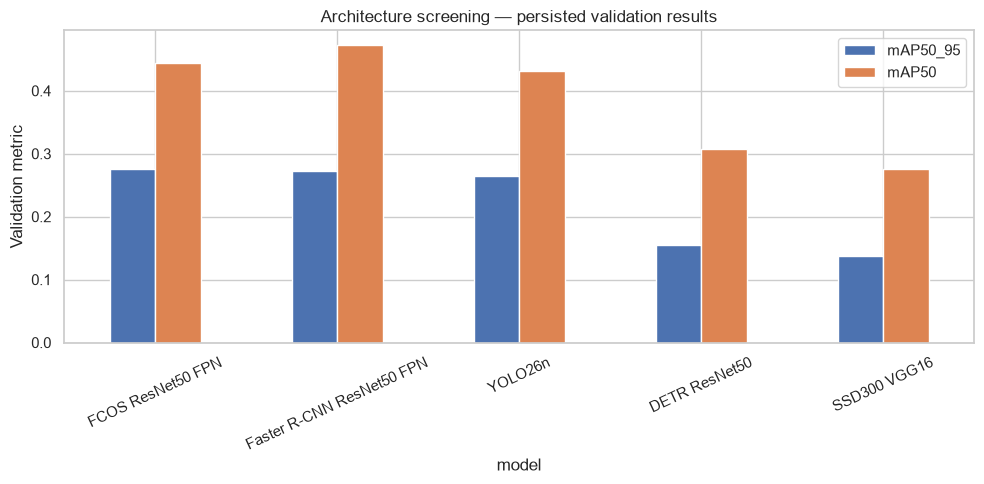

In [39]:
if summary.empty:
    print("No healthy completed experiments are available.")
else:
    leaderboard = summary.sort_values("mAP50_95", ascending=False, na_position="last").reset_index(drop=True)
    display(leaderboard)
    ax = leaderboard.plot.bar(x="model", y=[c for c in ["mAP50_95", "mAP50"] if c in leaderboard], figsize=(10, 5), rot=25)
    ax.set_ylabel("Validation metric"); ax.set_title("Architecture screening — persisted validation results"); plt.tight_layout(); plt.show()


The persisted ranking is FCOS **0.276385**, Faster R-CNN **0.272988**, YOLO26n **0.264111**, DETR **0.155492**, and SSD300 **0.137150**. FCOS has the highest primary validation metric, but its margin over Faster R-CNN is only about **0.00340**, while YOLO remains within about **0.01227**. DETR and SSD are substantially weaker under these particular screening configurations.

These results compare complete pretrained configurations. They do not establish universal superiority of anchor-free, two-stage, transformer-based, or YOLO-style detection.

## 6. $\mathrm{mAP}@0.5$ Comparison

Faster R-CNN has the highest persisted $\mathrm{mAP}@0.5$ at approximately **0.47213**, compared with **0.44382** for FCOS and **0.43117** for YOLO. FCOS nevertheless has the highest average AP across IoU thresholds from 0.5 to 0.95.

This means Faster R-CNN is strongest at the relaxed IoU=0.5 criterion, while FCOS is slightly stronger across the broader localization range. No configuration dominates every aggregate metric, and the small separation between the leading models should not be overinterpreted.

## 7. Per-Class Analysis

Aggregate mAP can hide failure on an underrepresented or visually difficult diagnosis. Per-class evidence is therefore examined for Impacted, Caries, Periapical Lesion, and Deep Caries, with particular attention to the baseline's weak Periapical Lesion behavior.

Historical persistence has an important limitation: `best_mAP50_95` stores the maximum aggregate value observed during training, while the saved `per_class` dictionary may come from the current or final epoch evaluation rather than the exact best checkpoint. Per-class results are useful diagnostic evidence, but they are not guaranteed to be checkpoint-consistent. Exact comparison would require a separate standardized evaluation of every persisted best checkpoint, which is deliberately not run during this refactor.

,experiment_id,class,precision,recall,AP50,AP50_95
0,E0_yolo26n_640_baseline,Impacted,0.730840,0.929293,0.912854,0.560375
1,E0_yolo26n_640_baseline,Caries,0.372364,0.492958,0.373898,0.253688
2,E0_yolo26n_640_baseline,Periapical Lesion,0.313893,0.080617,0.081095,0.043517
3,E0_yolo26n_640_baseline,Deep Caries,0.364439,0.411920,0.356851,0.198866
4,E1_ssd300,Impacted,NaN,0.526263,NaN,0.313243
5,E1_ssd300,Caries,NaN,0.413803,NaN,0.085279
6,E1_ssd300,Periapical Lesion,NaN,0.100000,NaN,0.024534
7,E1_ssd300,Deep Caries,NaN,0.335211,NaN,0.025452
8,E2_fcos_640,Impacted,NaN,0.660606,NaN,0.531049
9,E2_fcos_640,Caries,NaN,0.518873,NaN,0.227056


experiment_id,E0_yolo26n_640_baseline,E1_ssd300,E2_fcos_640,E3_fasterrcnn_640,E4_detr_640
class,,,,,
Caries,0.253688,0.085279,0.227056,0.170696,0.159546
Deep Caries,0.198866,0.025452,0.148221,0.177511,0.029678
Impacted,0.560375,0.313243,0.531049,0.526583,0.235734
Periapical Lesion,0.043517,0.024534,0.139775,0.107114,0.000000


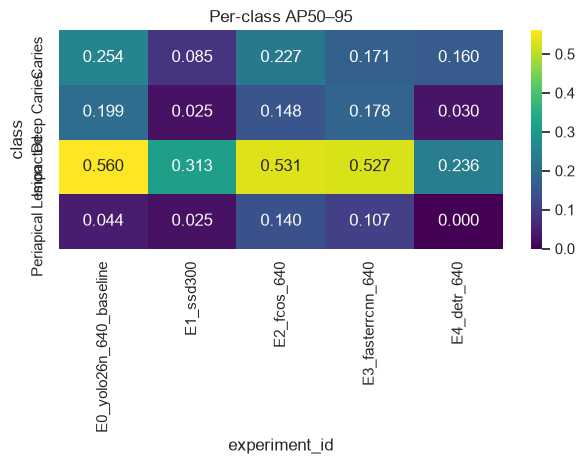

,experiment_id,small_object_recall
0,E0_yolo26n_640_baseline,NaN
1,E1_ssd300,NaN
2,E2_fcos_640,NaN
3,E3_fasterrcnn_640,NaN
4,E4_detr_640,NaN


In [8]:
def persisted_per_class() -> pd.DataFrame:
    rows = []
    for item in CANDIDATES:
        payload = read_json(artifact_paths(item)["metrics"])
        per_class = payload.get("per_class", {})
        if isinstance(per_class, list): iterable = enumerate(per_class)
        elif isinstance(per_class, dict): iterable = per_class.items()
        else: iterable = []
        for key, values in iterable:
            if not isinstance(values, dict): continue
            try: class_name = values.get("class_name") or CANONICAL_CLASS_NAMES.get(int(key), str(key))
            except (TypeError, ValueError): class_name = str(key)
            rows.append({"experiment_id": item.experiment_id, "class": class_name, "precision": values.get("precision", values.get("Precision")), "recall": values.get("recall", values.get("Recall")), "AP50": values.get("AP50", values.get("mAP50", values.get("AP@0.5"))), "AP50_95": values.get("AP50_95", values.get("mAP50_95", values.get("AP@0.5:0.95")))})
    return pd.DataFrame(rows)

per_class = persisted_per_class()
display(per_class)
if not per_class.empty and per_class["AP50_95"].notna().any():
    table = per_class.pivot(index="class", columns="experiment_id", values="AP50_95")
    display(table); sns.heatmap(table, annot=True, fmt=".3f", cmap="viridis"); plt.title("Per-class AP50–95"); plt.tight_layout(); plt.show()
if not summary.empty and "small_object_recall" in summary: display(summary[["experiment_id", "small_object_recall"]])


## 8. Interpreting FCOS Per-Class Behavior

The stored classwise values show Periapical Lesion AP increasing from **0.04352** for YOLO to **0.13977** for FCOS; Faster R-CNN records **0.10711**, SSD **0.02453**, and DETR **0.00000**. This is relevant because Periapical Lesion was the most severe baseline failure.

FCOS does not dominate every class. YOLO remains higher in the stored AP values for Impacted (**0.56038 vs. 0.53105**), Caries (**0.25369 vs. 0.22706**), and Deep Caries (**0.19887 vs. 0.14822**). FCOS is selected for its aggregate validation profile and its stronger diagnostic evidence on the weakest class, not for universal class-level superiority. Heterogeneous recall-like fields are not decisive evidence.

## 9. Training Dynamics

Training histories are read from disk without resuming any run. Best epochs differ materially: SSD reaches its recorded maximum at epoch 10, FCOS at epoch 5, Faster R-CNN at epoch 13, DETR at epoch 18, and YOLO at epoch 18. A uniform 20-epoch budget therefore does not imply equivalent optimization dynamics.

An early best epoch can indicate rapid improvement followed by plateau or degradation under the chosen settings, but it does not prove that an architecture is inherently faster to converge. Optimizers, learning rates, input policies, losses, and model capacities differ across the complete configurations.

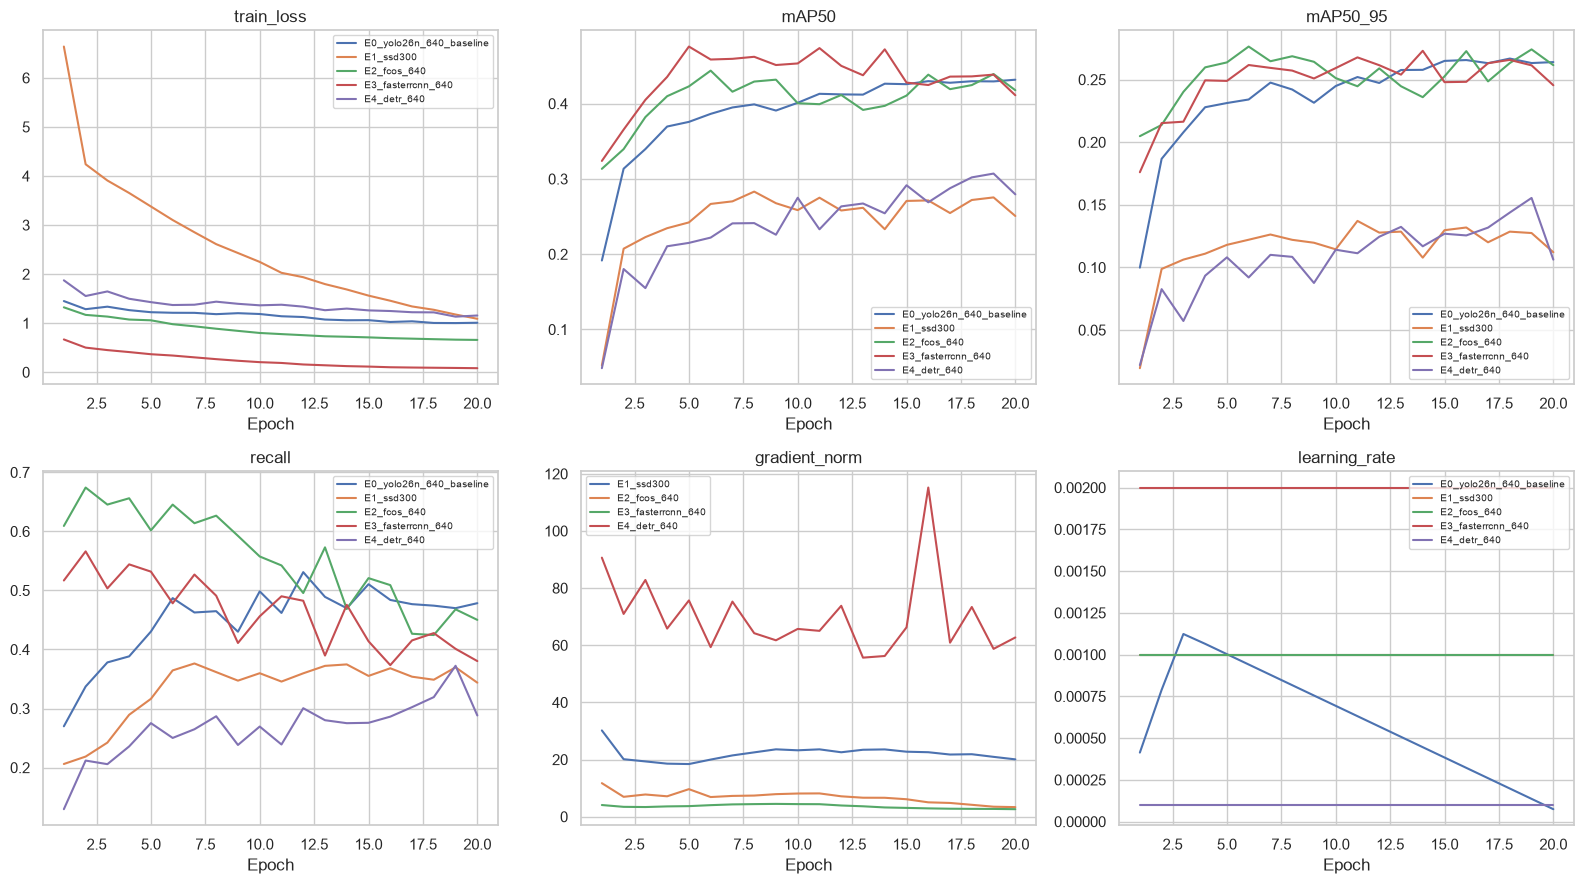

In [40]:
def load_histories(inventory=artifact_inventory) -> dict[str, pd.DataFrame]:
    histories = {}
    completed = set(inventory.loc[inventory.artifact_state.eq("COMPLETED"), "experiment_id"])
    for item in CANDIDATES:
        path = artifact_paths(item)["history"]
        if item.experiment_id in completed:
            try: histories[item.experiment_id] = pd.read_csv(path)
            except Exception as error: print(f"[SKIP] {item.experiment_id}: {error}")
    return histories

def plot_training_dynamics(histories: dict[str, pd.DataFrame]):
    aliases = {"train_loss": ["train_loss", "train/box_loss"], "mAP50": ["mAP50", "metrics/mAP50(B)"], "mAP50_95": ["mAP50_95", "metrics/mAP50-95(B)"], "recall": ["recall", "metrics/recall(B)"], "gradient_norm": ["mean_gradient_norm", "gradient_norm"], "learning_rate": ["learning_rate", "lr/pg0"]}
    fig, axes = plt.subplots(2, 3, figsize=(16, 9)); axes = axes.ravel()
    for axis, (label, choices) in zip(axes, aliases.items()):
        for experiment_id, history in histories.items():
            column = next((name for name in choices if name in history), None)
            if column: axis.plot(np.arange(1, len(history) + 1), history[column], label=experiment_id)
        axis.set_title(label); axis.set_xlabel("Epoch")
        if axis.lines: axis.legend(fontsize=7)
    plt.tight_layout(); plt.show()

histories = load_histories()
plot_training_dynamics(histories)


**Interpretation.** The curves retain framework-specific loss components and metric names rather than forcing incompatible histories into a false common scale. They support screening diagnostics, not causal claims about optimization speed.

## 10. Computational Trade-Offs

Training time is read from historical training histories. The remaining quantities are measured post hoc from the persisted best artifacts: total parameter count comes from each reconstructed trained model, artifact size is the actual checkpoint file size or the recursive size of the required DETR directory, and latency comes from a standardized validation benchmark.

The benchmark uses the same 12 deterministic validation images for every model, batch size 1, one common CUDA device when available (otherwise CPU), three untimed warm-up calls, and synchronized timing. Images are loaded into memory before timing. Each measurement includes framework-required preprocessing, forward inference, postprocessing, confidence filtering, and transfer of the resulting boxes, labels, and scores to CPU; it excludes checkpoint loading, model construction, image-disk I/O, plotting, and notebook setup. Framework internals differ, so the measurements are practical end-to-end comparisons rather than identical low-level kernels.

These measurements did not participate in the historical FCOS selection, which remains based on validation $\mathrm{mAP}@0.5{:}0.95$. They provide supplementary engineering characterization only.

In [41]:
def build_torchvision_architecture(family: str):
    from functools import partial
    from torch import nn
    from torchvision.models.detection import fcos_resnet50_fpn, fasterrcnn_resnet50_fpn, ssd300_vgg16
    from torchvision.models.detection.faster_rcnn import FastRCNNPredictor
    from torchvision.models.detection.fcos import FCOSClassificationHead
    from torchvision.models.detection.ssd import SSDClassificationHead

    if family == "ssd":
        model = ssd300_vgg16(weights=None, weights_backbone=None)
        model.head.classification_head = SSDClassificationHead(
            [512, 1024, 512, 256, 256, 256],
            model.anchor_generator.num_anchors_per_location(),
            5,
        )
    elif family == "fcos":
        model = fcos_resnet50_fpn(weights=None, weights_backbone=None)
        model.head.classification_head = FCOSClassificationHead(
            model.backbone.out_channels,
            model.anchor_generator.num_anchors_per_location()[0],
            5,
            norm_layer=partial(nn.GroupNorm, 32),
        )
    elif family == "faster_rcnn":
        model = fasterrcnn_resnet50_fpn(weights=None, weights_backbone=None)
        features = model.roi_heads.box_predictor.cls_score.in_features
        model.roi_heads.box_predictor = FastRCNNPredictor(features, 5)
    else:
        raise ValueError(f"Unsupported torchvision family: {family}")
    return model


def load_best_torchvision_model(item: Candidate, device: torch.device):
    checkpoint_path = artifact_paths(item)["best"]
    if not checkpoint_path.is_file():
        raise FileNotFoundError(f"Trained BEST checkpoint is missing: {checkpoint_path}")
    checkpoint = torch.load(checkpoint_path, map_location="cpu", weights_only=False)
    model = build_torchvision_architecture(item.family)
    model.load_state_dict(checkpoint["model_state_dict"], strict=True)
    return model.to(device).eval()


def to_common_prediction(boxes, labels, scores, label_offset=0) -> dict[str, object]:
    boxes = torch.as_tensor(boxes, dtype=torch.float32).detach().cpu().reshape(-1, 4)
    labels = torch.as_tensor(labels, dtype=torch.int64).detach().cpu().reshape(-1) - label_offset
    scores = torch.as_tensor(scores, dtype=torch.float32).detach().cpu().reshape(-1)
    if len(boxes) != len(labels) or len(labels) != len(scores):
        raise RuntimeError("Prediction boxes, labels, and scores have inconsistent lengths.")
    if len(labels) and not bool(torch.all((labels >= 0) & (labels < len(CANONICAL_CLASS_NAMES)))):
        raise RuntimeError(f"Prediction contains labels outside canonical IDs 0..3: {labels.tolist()}")
    return {
        "boxes": boxes,
        "labels": labels,
        "class_names": [CANONICAL_CLASS_NAMES[int(label)] for label in labels],
        "scores": scores,
    }


def infer_torchvision_cases(item, cases, device, confidence_threshold):
    model = load_best_torchvision_model(item, device)
    predictions = {}
    try:
        with torch.inference_mode():
            for row in cases.itertuples(index=False):
                image = Image.open(VAL_IMAGES / row.file_name).convert("RGB")
                output = model([TF.to_tensor(image).to(device)])[0]
                keep = output["scores"] >= confidence_threshold
                predictions[int(row.image_id)] = to_common_prediction(
                    output["boxes"][keep], output["labels"][keep], output["scores"][keep], label_offset=1
                )
    finally:
        model.to("cpu")
        del model
        gc.collect()
        if torch.cuda.is_available():
            torch.cuda.empty_cache()
    return predictions


def infer_yolo_cases(item, cases, device, confidence_threshold):
    from ultralytics import YOLO

    checkpoint_path = artifact_paths(item)["best"]
    if not checkpoint_path.is_file():
        raise FileNotFoundError(f"Trained BEST checkpoint is missing: {checkpoint_path}")
    model = YOLO(checkpoint_path)
    predictions = {}
    try:
        for row in cases.itertuples(index=False):
            result = model.predict(
                source=str(VAL_IMAGES / row.file_name),
                imgsz=item.image_size,
                conf=confidence_threshold,
                device=0 if device.type == "cuda" else "cpu",
                verbose=False,
            )[0]
            predictions[int(row.image_id)] = to_common_prediction(
                result.boxes.xyxy, result.boxes.cls, result.boxes.conf
            )
    finally:
        del model
        gc.collect()
        if torch.cuda.is_available():
            torch.cuda.empty_cache()
    return predictions


def infer_detr_cases(item, cases, device, confidence_threshold):
    from transformers import AutoImageProcessor, DetrForObjectDetection

    checkpoint_path = artifact_paths(item)["best"]
    if not checkpoint_path.is_dir():
        raise FileNotFoundError(f"Trained BEST DETR directory is missing: {checkpoint_path}")
    processor = AutoImageProcessor.from_pretrained(checkpoint_path, local_files_only=True)
    model = DetrForObjectDetection.from_pretrained(checkpoint_path, local_files_only=True).to(device).eval()
    predictions = {}
    try:
        with torch.inference_mode():
            for row in cases.itertuples(index=False):
                image = Image.open(VAL_IMAGES / row.file_name).convert("RGB")
                inputs = processor(images=image, return_tensors="pt").to(device)
                output = model(**inputs)
                restored = processor.post_process_object_detection(
                    output,
                    target_sizes=torch.tensor([[image.height, image.width]], device=device),
                    threshold=confidence_threshold,
                )[0]
                predictions[int(row.image_id)] = to_common_prediction(
                    restored["boxes"], restored["labels"], restored["scores"]
                )
    finally:
        model.to("cpu")
        del model, processor
        gc.collect()
        if torch.cuda.is_available():
            torch.cuda.empty_cache()
    return predictions


def ground_truth_for_image(image_id: int) -> dict[str, object]:
    coco, grouped = load_validation_index()
    annotations = grouped[int(image_id)]
    boxes = []
    labels = []
    for annotation in annotations:
        x, y, width, height = annotation["bbox"]
        boxes.append([x, y, x + width, y + height])
        labels.append(int(annotation["category_id"]))
    return to_common_prediction(boxes, labels, [1.0] * len(labels))


def draw_detection_panel(image: Image.Image, prediction: dict, ground_truth=False) -> Image.Image:
    panel = image.copy()
    draw = ImageDraw.Draw(panel)
    color = "lime" if ground_truth else "red"
    for box, class_name, score in zip(prediction["boxes"].tolist(), prediction["class_names"], prediction["scores"].tolist()):
        draw.rectangle(box, outline=color, width=3)
        label = class_name if ground_truth else f"{class_name} {score:.2f}"
        draw.text((box[0] + 2, box[1] + 2), label, fill=color, stroke_width=2, stroke_fill="black")
    return panel


def display_qualitative_panels(cases, predictions_by_model):
    model_order = [(item.experiment_id, item.model_name) for item in CANDIDATES]
    for row in cases.itertuples(index=False):
        source = Image.open(VAL_IMAGES / row.file_name).convert("RGB")
        panels = [("Ground Truth", draw_detection_panel(source, ground_truth_for_image(row.image_id), ground_truth=True))]
        panels.extend(
            (model_name, draw_detection_panel(source, predictions_by_model[experiment_id][int(row.image_id)]))
            for experiment_id, model_name in model_order
        )
        figure, axes = plt.subplots(1, len(panels), figsize=(24, 5))
        for axis, (title, panel) in zip(axes, panels):
            axis.imshow(panel)
            axis.set_title(title, fontsize=10)
            axis.axis("off")
        figure.suptitle(f"{row.case}: image_id={row.image_id}, file={row.file_name}", fontsize=12)
        plt.tight_layout()
        plt.show()


def run_qualitative_comparison(cases, confidence_threshold=0.25):
    """Run persisted BEST checkpoints sequentially on one fixed validation case set."""
    required = [item for item in CANDIDATES if item.experiment_id in set(summary["experiment_id"])]
    unavailable = [item.experiment_id for item in required if not artifact_paths(item)["best"].exists()]
    if unavailable:
        print({"unavailable_model_artifacts": unavailable})
        raise FileNotFoundError(f"Required trained BEST artifacts are unavailable: {unavailable}")

    device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
    predictions_by_model = {}
    evaluated = []
    for item in required:
        print(f"[QUALITATIVE] {item.experiment_id}: loading {artifact_paths(item)['best']}")
        if item.family == "yolo":
            predictions = infer_yolo_cases(item, cases, device, confidence_threshold)
        elif item.family == "detr":
            predictions = infer_detr_cases(item, cases, device, confidence_threshold)
        else:
            predictions = infer_torchvision_cases(item, cases, device, confidence_threshold)
        predictions_by_model[item.experiment_id] = predictions
        evaluated.append(item.experiment_id)
        print(f"[QUALITATIVE] {item.experiment_id}: complete; model memory released")

    display_qualitative_panels(cases, predictions_by_model)
    summary_payload = {
        "selected_validation_images": cases[["image_id", "file_name", "case"]].to_dict("records"),
        "models_evaluated": evaluated,
        "unavailable_model_artifacts": unavailable,
        "confidence_threshold": confidence_threshold,
    }
    print("Qualitative comparison summary")
    print(json.dumps(summary_payload, indent=2))
    return predictions_by_model, summary_payload


In [42]:
BENCHMARK_IMAGE_COUNT = 12
BENCHMARK_BATCH_SIZE = 1
WARMUP_RUNS = 3
BENCHMARK_CONFIDENCE_THRESHOLD = 0.25
BENCHMARK_DEVICE = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
PROFILING_PATH = PATHS.root / "artifacts" / "comparison" / "model_profiling.csv"
RUN_MODEL_PROFILING = False


def select_benchmark_validation_images(count=BENCHMARK_IMAGE_COUNT) -> pd.DataFrame:
    coco = read_json(VAL_JSON)
    rows = [
        {
            "image_id": int(item["id"]),
            "file_name": item["file_name"],
            "selection_key": hashlib.sha256(f"benchmark:{SEED}:{item['id']}".encode()).hexdigest(),
        }
        for item in coco["images"]
    ]
    if len(rows) < count:
        raise RuntimeError(f"Requested {count} benchmark images, but validation contains only {len(rows)}.")
    return pd.DataFrame(sorted(rows, key=lambda row: row["selection_key"])[:count]).drop(columns="selection_key")


def preload_benchmark_images(cases: pd.DataFrame) -> list[tuple[int, str, Image.Image]]:
    loaded = []
    for row in cases.itertuples(index=False):
        with Image.open(VAL_IMAGES / row.file_name) as image:
            loaded.append((int(row.image_id), row.file_name, image.convert("RGB").copy()))
    return loaded


def artifact_size_mib(artifact: Path) -> float:
    if artifact.is_file():
        size = artifact.stat().st_size
    elif artifact.is_dir():
        size = sum(item.stat().st_size for item in artifact.rglob("*") if item.is_file())
    else:
        raise FileNotFoundError(f"Persisted BEST artifact is missing: {artifact}")
    return size / (1024 ** 2)


def artifact_sha256(artifact: Path) -> str:
    digest = hashlib.sha256()
    files = [artifact] if artifact.is_file() else sorted(item for item in artifact.rglob("*") if item.is_file())
    if not files:
        raise FileNotFoundError(f"Persisted BEST artifact is empty or missing: {artifact}")
    for item in files:
        digest.update(str(item.relative_to(artifact.parent)).replace("\\", "/").encode())
        with item.open("rb") as handle:
            for chunk in iter(lambda: handle.read(1024 * 1024), b""):
                digest.update(chunk)
    return digest.hexdigest()


def synchronize_benchmark_device() -> None:
    if BENCHMARK_DEVICE.type == "cuda":
        torch.cuda.synchronize(BENCHMARK_DEVICE)


def release_profiled_model(model, processor=None) -> None:
    try:
        torch_model = model.model if hasattr(model, "model") else model
        if hasattr(torch_model, "to"):
            torch_model.to("cpu")
    finally:
        del model
        if processor is not None:
            del processor
        gc.collect()
        if torch.cuda.is_available():
            torch.cuda.empty_cache()


def load_profile_model(item: Candidate):
    artifact = artifact_paths(item)["best"]
    if not artifact.exists():
        raise FileNotFoundError(f"Trained BEST artifact is missing: {artifact}")
    if item.family == "yolo":
        from ultralytics import YOLO
        model = YOLO(artifact)
        model.model.to(BENCHMARK_DEVICE).eval()
        return model, None
    if item.family == "detr":
        from transformers import AutoImageProcessor, DetrForObjectDetection
        processor = AutoImageProcessor.from_pretrained(artifact, local_files_only=True)
        model = DetrForObjectDetection.from_pretrained(artifact, local_files_only=True).to(BENCHMARK_DEVICE).eval()
        return model, processor
    return load_best_torchvision_model(item, BENCHMARK_DEVICE), None


def profile_inference_call(item, model, processor, image):
    """Timed boundary: in-memory image preprocessing through CPU detection output."""
    with torch.inference_mode():
        if item.family == "yolo":
            result = model.predict(
                source=image,
                imgsz=item.image_size,
                conf=BENCHMARK_CONFIDENCE_THRESHOLD,
                device=0 if BENCHMARK_DEVICE.type == "cuda" else "cpu",
                verbose=False,
            )[0]
            return to_common_prediction(result.boxes.xyxy, result.boxes.cls, result.boxes.conf)
        if item.family == "detr":
            inputs = processor(images=image, return_tensors="pt").to(BENCHMARK_DEVICE)
            output = model(**inputs)
            restored = processor.post_process_object_detection(
                output,
                target_sizes=torch.tensor([[image.height, image.width]], device=BENCHMARK_DEVICE),
                threshold=BENCHMARK_CONFIDENCE_THRESHOLD,
            )[0]
            return to_common_prediction(restored["boxes"], restored["labels"], restored["scores"])
        output = model([TF.to_tensor(image).to(BENCHMARK_DEVICE)])[0]
        keep = output["scores"] >= BENCHMARK_CONFIDENCE_THRESHOLD
        return to_common_prediction(output["boxes"][keep], output["labels"][keep], output["scores"][keep], label_offset=1)


def profile_completed_models(cases: pd.DataFrame) -> pd.DataFrame:
    images = preload_benchmark_images(cases)
    completed = set(artifact_inventory.loc[artifact_inventory.artifact_state.eq("COMPLETED"), "experiment_id"])
    rows = []
    for item in CANDIDATES:
        if item.experiment_id not in completed:
            continue
        artifact = artifact_paths(item)["best"]
        model = processor = None
        base = {
            "experiment_id": item.experiment_id,
            "model": item.model_name,
            "checkpoint_path": str(artifact.resolve()),
            "benchmark_device": str(BENCHMARK_DEVICE),
            "benchmark_batch_size": BENCHMARK_BATCH_SIZE,
            "benchmark_image_count": len(images),
            "warmup_runs": WARMUP_RUNS,
            "confidence_threshold": BENCHMARK_CONFIDENCE_THRESHOLD,
            "benchmark_timestamp": pd.Timestamp.now(tz="UTC").isoformat(),
        }
        try:
            model, processor = load_profile_model(item)
            torch_model = model.model if item.family == "yolo" else model
            parameter_count = sum(parameter.numel() for parameter in torch_model.parameters())

            for index in range(WARMUP_RUNS):
                profile_inference_call(item, model, processor, images[index % len(images)][2])
            synchronize_benchmark_device()

            measurements = []
            for _, _, image in images:
                synchronize_benchmark_device()
                started = time.perf_counter()
                prediction = profile_inference_call(item, model, processor, image)
                synchronize_benchmark_device()
                measurements.append((time.perf_counter() - started) * 1000.0)
                del prediction

            rows.append({
                **base,
                "checkpoint_sha256": artifact_sha256(artifact),
                "parameter_count": int(parameter_count),
                "model_size_mb": artifact_size_mib(artifact),
                "inference_latency_ms": float(np.median(measurements)),
                "inference_latency_mean_ms": float(np.mean(measurements)),
                "inference_latency_std_ms": float(np.std(measurements, ddof=1)) if len(measurements) > 1 else 0.0,
                "profiling_status": "OK",
                "profiling_error": "",
            })
        except Exception as error:
            rows.append({
                **base,
                "checkpoint_sha256": np.nan,
                "parameter_count": np.nan,
                "model_size_mb": artifact_size_mib(artifact) if artifact.exists() else np.nan,
                "inference_latency_ms": np.nan,
                "inference_latency_mean_ms": np.nan,
                "inference_latency_std_ms": np.nan,
                "profiling_status": "UNAVAILABLE",
                "profiling_error": f"{type(error).__name__}: {error}",
            })
            print(f"[PROFILE][UNAVAILABLE] {item.experiment_id}: {type(error).__name__}: {error}")
        finally:
            if model is not None:
                release_profiled_model(model, processor)
            else:
                gc.collect()
                if torch.cuda.is_available():
                    torch.cuda.empty_cache()
    return pd.DataFrame(rows)


def load_or_run_model_profiling(run_profiling=RUN_MODEL_PROFILING):
    benchmark_cases = select_benchmark_validation_images()
    print(f"Benchmark device: {BENCHMARK_DEVICE}; batch size: {BENCHMARK_BATCH_SIZE}")
    display(benchmark_cases)
    if run_profiling:
        profiling = profile_completed_models(benchmark_cases)
        PROFILING_PATH.parent.mkdir(parents=True, exist_ok=True)
        profiling.to_csv(PROFILING_PATH, index=False)
        print(f"Persisted profiling results: {PROFILING_PATH}")
    elif PROFILING_PATH.is_file():
        profiling = pd.read_csv(PROFILING_PATH)
        print(f"Loaded persisted profiling results: {PROFILING_PATH}")
    else:
        profiling = pd.DataFrame()
        print("No persisted profiling results are available. Set RUN_MODEL_PROFILING=True for one measured run.")
    return benchmark_cases, profiling


benchmark_cases, model_profiling = load_or_run_model_profiling()

profile_columns = [
    "experiment_id", "parameter_count", "model_size_mb", "inference_latency_ms",
    "inference_latency_mean_ms", "inference_latency_std_ms", "benchmark_device",
    "benchmark_batch_size", "benchmark_image_count", "warmup_runs", "profiling_status", "profiling_error",
]
summary = summary.drop(
    columns=["parameter_count", "model_size_mb", "inference_latency_ms"], errors="ignore"
)
if not model_profiling.empty:
    summary = summary.merge(model_profiling[profile_columns], on="experiment_id", how="left")
else:
    summary[["parameter_count", "model_size_mb", "inference_latency_ms"]] = np.nan

display(summary[[
    "experiment_id", "mAP50_95", "inference_latency_ms", "parameter_count", "model_size_mb"
]])


Benchmark device: cuda:0; batch size: 1


,image_id,file_name
0,349,train_27.png
1,52,train_655.png
2,393,train_173.png
3,171,train_415.png
4,321,train_620.png
5,589,train_701.png
6,181,train_84.png
7,691,train_194.png
8,494,train_89.png
9,267,train_674.png


Loaded persisted profiling results: C:\Users\Eclipse\PycharmProjects\Dental-Xray-Pathology-Detection\artifacts\comparison\model_profiling.csv


,experiment_id,mAP50_95,inference_latency_ms,parameter_count,model_size_mb
0,E0_yolo26n_640_baseline,0.264111,50.2363,2505360,5.117253
1,E1_ssd300,0.137150,69.7619,24146894,184.119197
2,E2_fcos_640,0.276385,143.2726,32124490,244.356401
3,E3_fasterrcnn_640,0.272988,149.5836,41367656,314.866457
4,E4_detr_640,0.155492,154.0567,41502409,158.786942


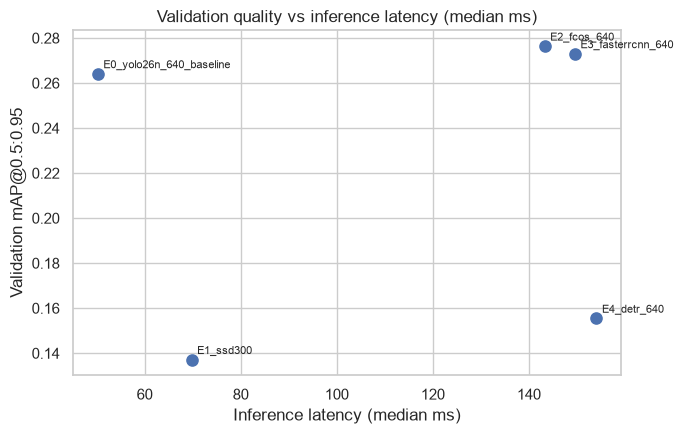

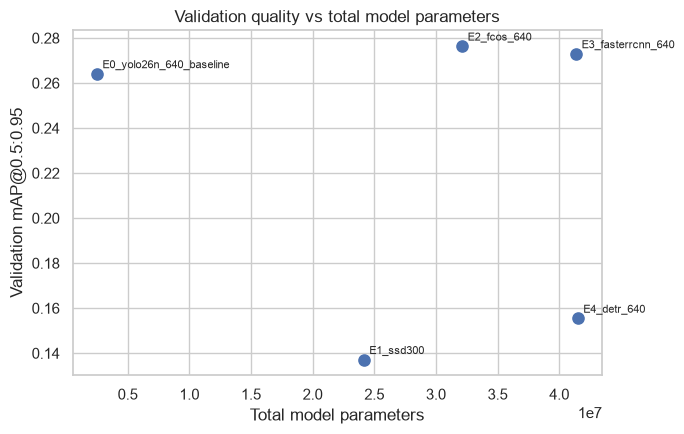

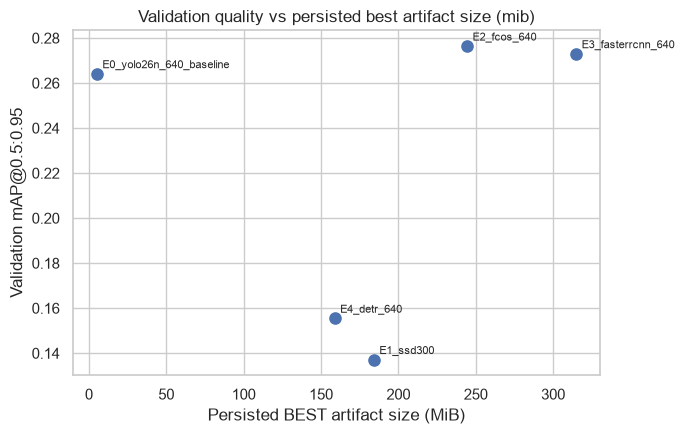

In [43]:
def plot_tradeoffs(frame: pd.DataFrame):
    if frame.empty:
        print("Trade-off plots skipped: the comparison summary is empty.")
        return
    specifications = [
        ("inference_latency_ms", "Inference latency (median ms)", "Latency trade-off"),
        ("parameter_count", "Total model parameters", "Parameter-count trade-off"),
        ("model_size_mb", "Persisted BEST artifact size (MiB)", "Artifact-size trade-off"),
    ]
    for column, x_label, description in specifications:
        valid = frame.dropna(subset=[column, "mAP50_95"])
        if valid.empty:
            print(f"{description} plot skipped: no measured {column} values are available.")
            continue
        figure, axis = plt.subplots(figsize=(7, 4.5))
        axis.scatter(valid[column], valid["mAP50_95"], s=65)
        for _, row in valid.iterrows():
            axis.annotate(row["experiment_id"], (row[column], row["mAP50_95"]), xytext=(4, 4), textcoords="offset points", fontsize=8)
        axis.set_xlabel(x_label)
        axis.set_ylabel("Validation mAP@0.5:0.95")
        axis.set_title(f"Validation quality vs {x_label.lower()}")
        plt.tight_layout()
        plt.show()


plot_tradeoffs(summary)


## 11. Optional Qualitative Comparison

This opt-in section applies every completed detector to the same six deterministically selected validation images: a typical case, a dense case, a Periapical Lesion case, a Deep Caries case, a small-object case, and a negative image. Selection uses only the canonical validation annotations and seed 42; the test split is not referenced.

Before inference, the pipeline verifies that every required persisted best checkpoint exists. Each architecture is then loaded without generic pretrained weights, evaluated separately, converted to a common `XYXY + canonical label + score` representation on CPU, and released before the next model is loaded. A common confidence threshold is used for visualization. Set `RUN_QUALITATIVE_INFERENCE = True` only when the complete comparison panels are required.

In [44]:
def load_validation_index() -> tuple[dict, dict[int, list[dict]]]:
    coco = read_json(VAL_JSON)
    grouped = {item["id"]: [] for item in coco["images"]}
    for annotation in coco["annotations"]:
        grouped.setdefault(annotation["image_id"], []).append(annotation)
    return coco, grouped


def select_qualitative_validation_cases() -> pd.DataFrame:
    """Select six reproducible, distinct validation cases from annotation content."""
    coco, grouped = load_validation_index()
    records = []
    for info in sorted(coco["images"], key=lambda item: item["id"]):
        annotations = grouped.get(info["id"], [])
        relative_areas = [
            (float(annotation["bbox"][2]) * float(annotation["bbox"][3]))
            / (float(info["width"]) * float(info["height"]))
            for annotation in annotations
        ]
        records.append({
            "image_id": int(info["id"]),
            "file_name": info["file_name"],
            "objects": len(annotations),
            "class_ids": {int(annotation["category_id"]) for annotation in annotations},
            "minimum_relative_area": min(relative_areas, default=np.nan),
            "selection_key": hashlib.sha256(f"{SEED}:{info['id']}".encode()).hexdigest(),
        })

    used = set()

    def choose(role, predicate, sort_key):
        eligible = [record for record in records if record["image_id"] not in used and predicate(record)]
        if not eligible:
            raise RuntimeError(f"No distinct validation image satisfies qualitative role: {role}")
        selected = min(eligible, key=sort_key)
        used.add(selected["image_id"])
        return {"case": role, **selected}

    positive_counts = [record["objects"] for record in records if record["objects"] > 0]
    median_count = float(np.median(positive_counts))
    selected = [
        choose("typical", lambda row: row["objects"] > 0, lambda row: (abs(row["objects"] - median_count), row["selection_key"])),
        choose("dense", lambda row: row["objects"] > 0, lambda row: (-row["objects"], row["selection_key"])),
        choose("periapical_lesion", lambda row: 2 in row["class_ids"], lambda row: row["selection_key"]),
        choose("deep_caries", lambda row: 3 in row["class_ids"], lambda row: row["selection_key"]),
        choose("small_object", lambda row: np.isfinite(row["minimum_relative_area"]), lambda row: (row["minimum_relative_area"], row["selection_key"])),
        choose("negative", lambda row: row["objects"] == 0, lambda row: row["selection_key"]),
    ]
    frame = pd.DataFrame(selected)
    frame["classes"] = frame["class_ids"].map(lambda ids: [CANONICAL_CLASS_NAMES[index] for index in sorted(ids)])
    return frame.drop(columns=["class_ids", "selection_key"])


qualitative_cases = select_qualitative_validation_cases()
display(qualitative_cases)


,case,image_id,file_name,objects,minimum_relative_area,classes
0,typical,456,train_237.png,5,0.008919,[Caries]
1,dense,148,train_273.png,23,0.006978,"[Impacted, Caries, Periapical Lesion, Deep Car..."
2,periapical_lesion,228,train_213.png,3,0.008172,"[Caries, Periapical Lesion, Deep Caries]"
3,deep_caries,653,train_350.png,3,0.020103,"[Caries, Deep Caries]"
4,small_object,308,train_200.png,8,0.002853,"[Caries, Deep Caries]"
5,negative,355,train_571.png,0,NaN,[]


[QUALITATIVE] E0_yolo26n_640_baseline: loading C:\Users\Eclipse\PycharmProjects\Dental-Xray-Pathology-Detection\artifacts\baseline\yolo26n_640_seed42\weights\best.pt
[QUALITATIVE] E0_yolo26n_640_baseline: complete; model memory released
[QUALITATIVE] E1_ssd300: loading C:\Users\Eclipse\PycharmProjects\Dental-Xray-Pathology-Detection\artifacts\experiments\ssd300_seed42\best.pth
[QUALITATIVE] E1_ssd300: complete; model memory released
[QUALITATIVE] E2_fcos_640: loading C:\Users\Eclipse\PycharmProjects\Dental-Xray-Pathology-Detection\artifacts\experiments\fcos_seed42\best.pth
[QUALITATIVE] E2_fcos_640: complete; model memory released
[QUALITATIVE] E3_fasterrcnn_640: loading C:\Users\Eclipse\PycharmProjects\Dental-Xray-Pathology-Detection\artifacts\experiments\fasterrcnn_seed42\best.pth
[QUALITATIVE] E3_fasterrcnn_640: complete; model memory released
[QUALITATIVE] E4_detr_640: loading C:\Users\Eclipse\PycharmProjects\Dental-Xray-Pathology-Detection\artifacts\experiments\detr_seed42\best


Loading weights: 100%|██████████| 530/530 [00:00<00:00, 2733.46it/s]


[QUALITATIVE] E4_detr_640: complete; model memory released


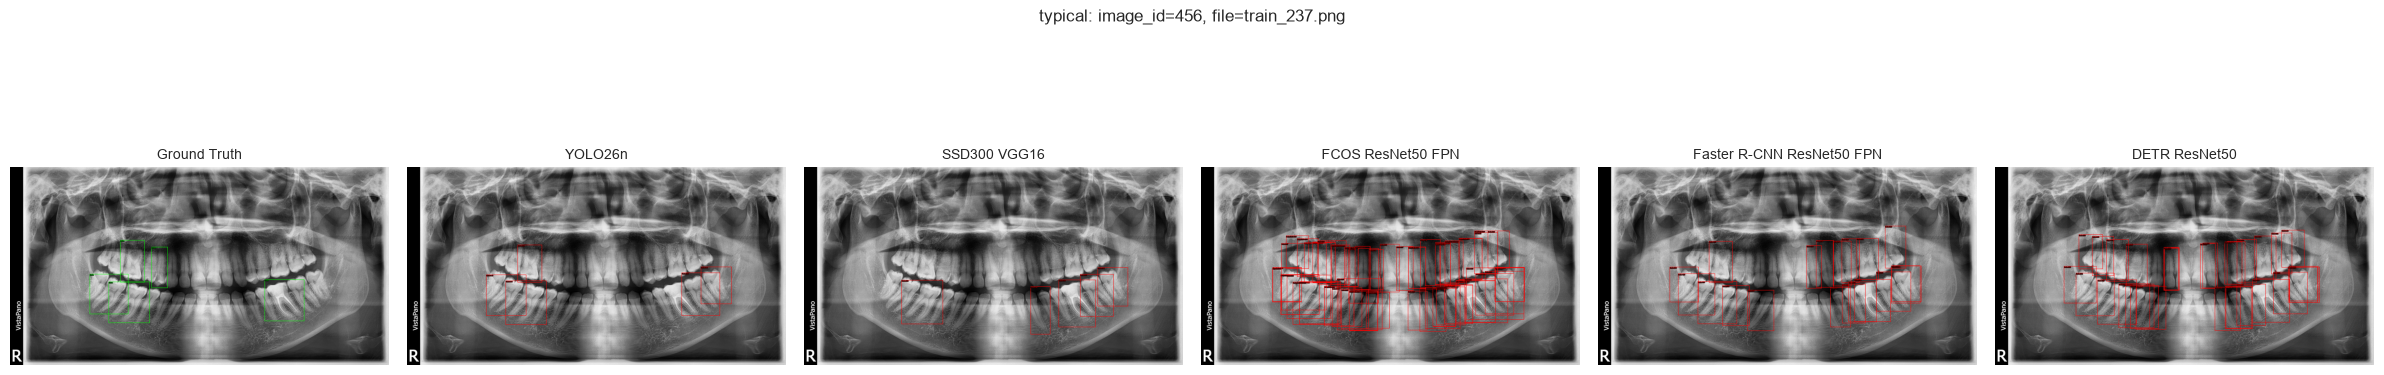

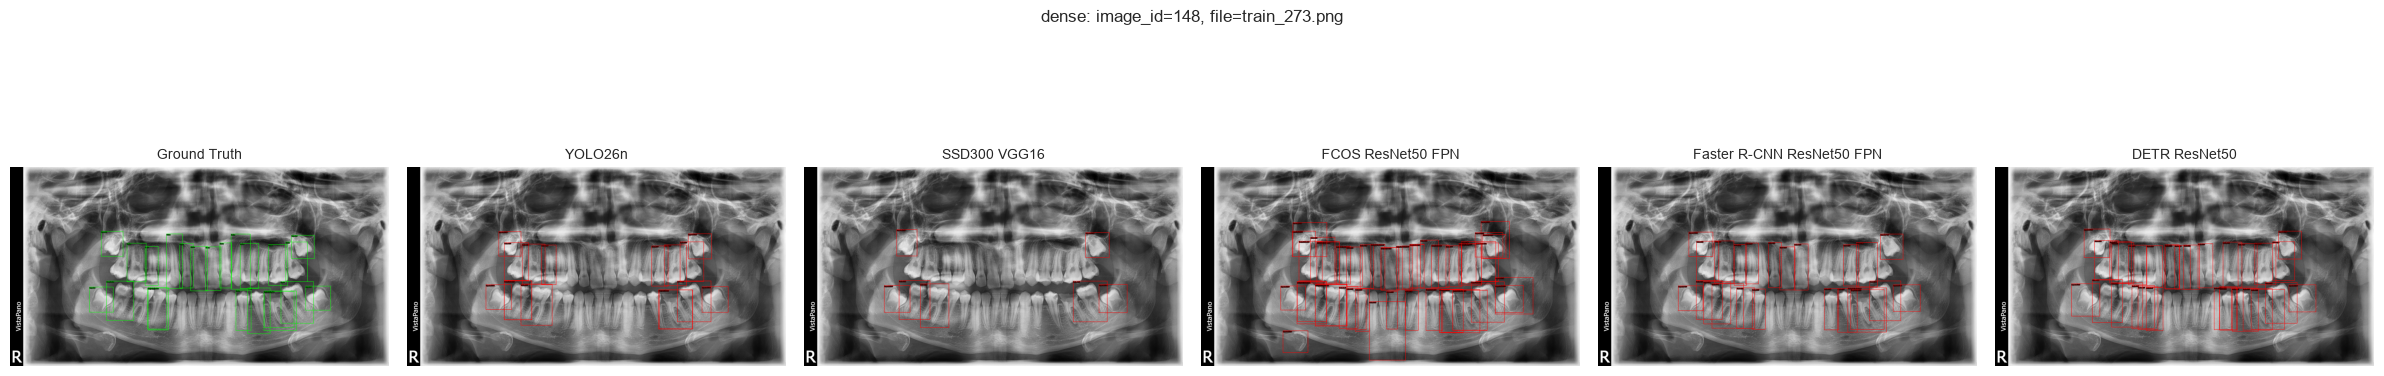

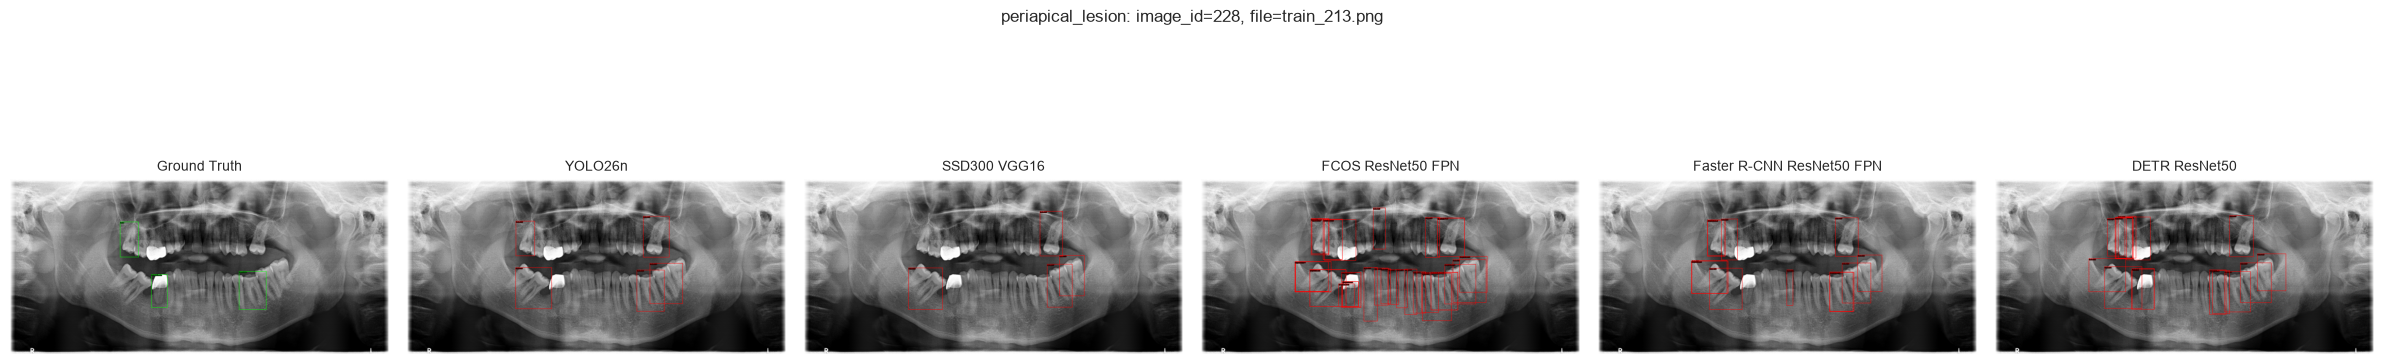

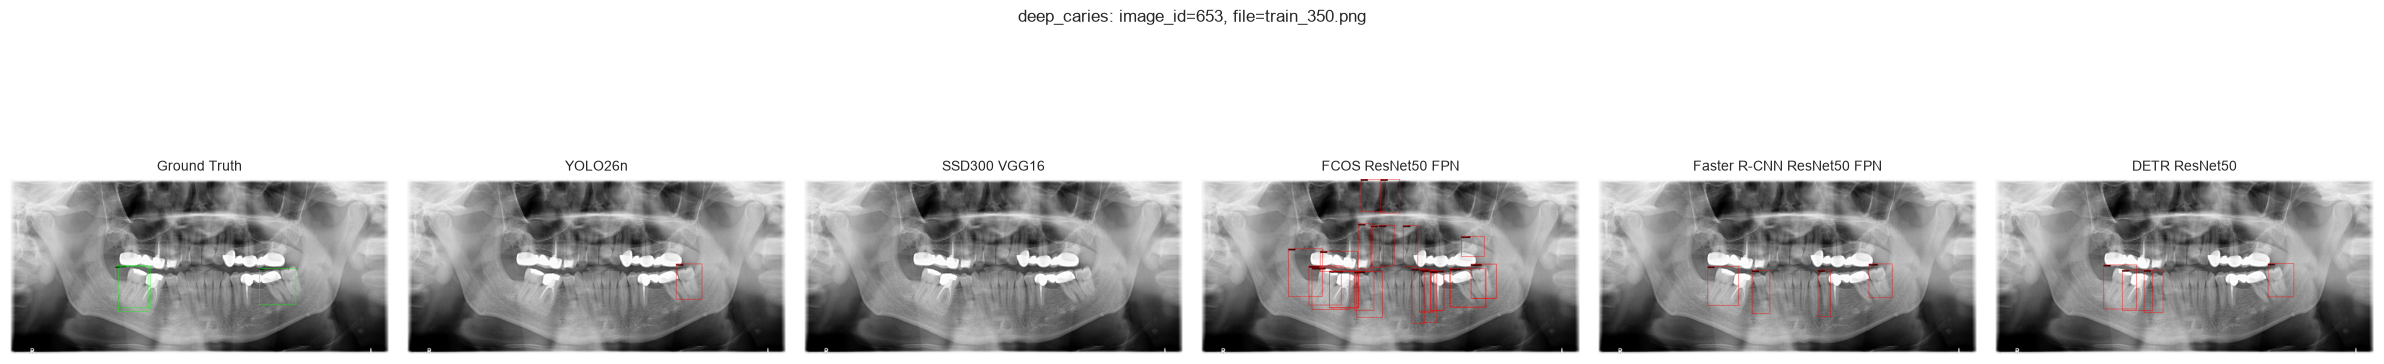

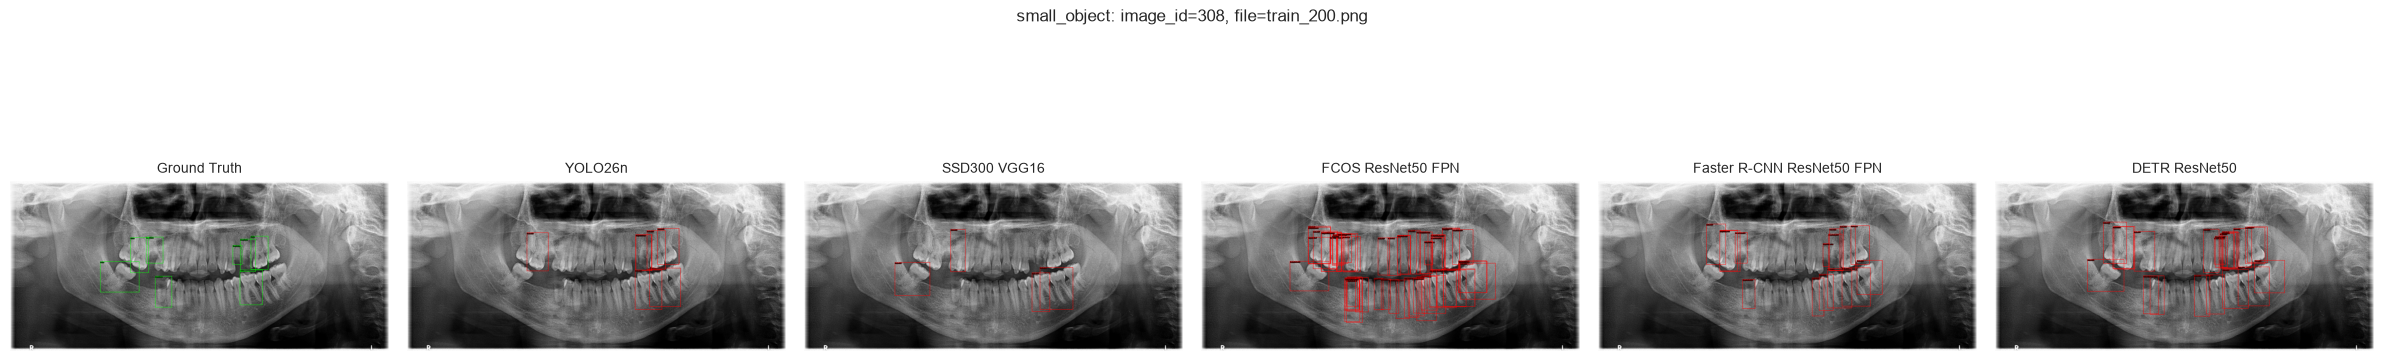

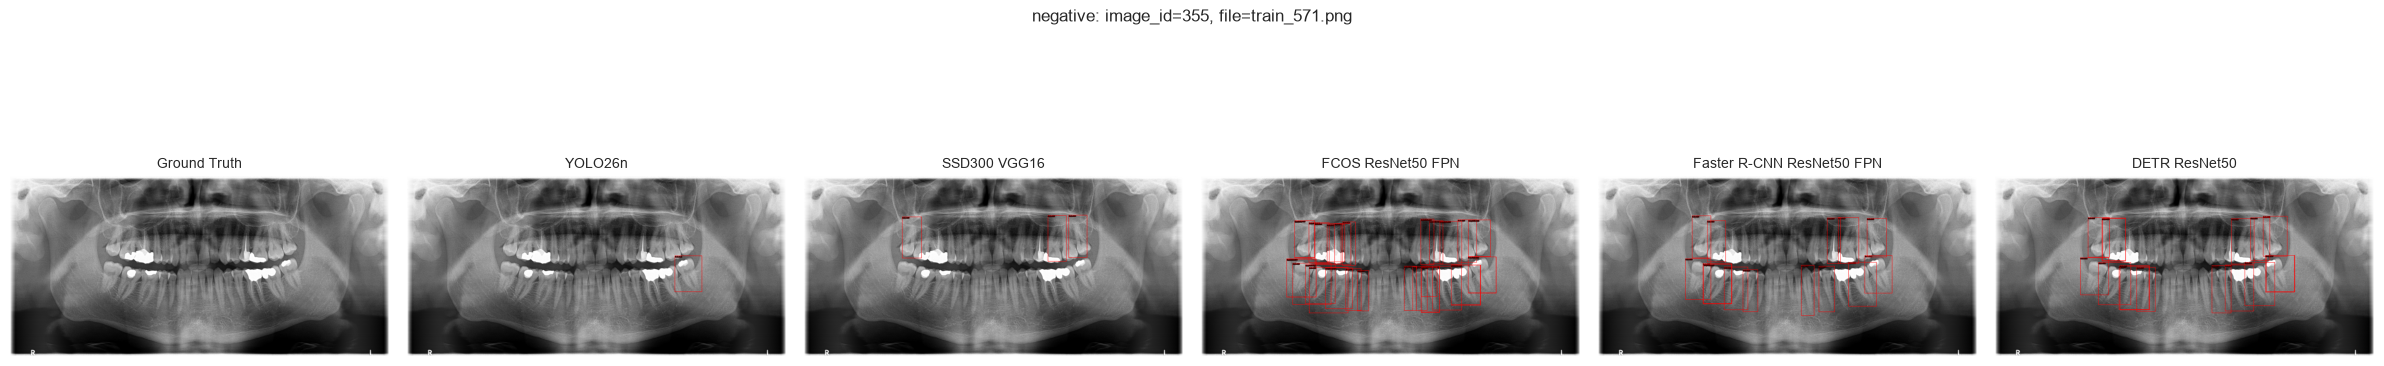

Qualitative comparison summary
{
  "selected_validation_images": [
    {
      "image_id": 456,
      "file_name": "train_237.png",
      "case": "typical"
    },
    {
      "image_id": 148,
      "file_name": "train_273.png",
      "case": "dense"
    },
    {
      "image_id": 228,
      "file_name": "train_213.png",
      "case": "periapical_lesion"
    },
    {
      "image_id": 653,
      "file_name": "train_350.png",
      "case": "deep_caries"
    },
    {
      "image_id": 308,
      "file_name": "train_200.png",
      "case": "small_object"
    },
    {
      "image_id": 355,
      "file_name": "train_571.png",
      "case": "negative"
    }
  ],
  "models_evaluated": [
    "E0_yolo26n_640_baseline",
    "E1_ssd300",
    "E2_fcos_640",
    "E3_fasterrcnn_640",
    "E4_detr_640"
  ],
  "unavailable_model_artifacts": [],
  "confidence_threshold": 0.25
}


In [45]:
RUN_QUALITATIVE_INFERENCE = True
QUALITATIVE_CONFIDENCE_THRESHOLD = 0.25

if RUN_QUALITATIVE_INFERENCE:
    qualitative_predictions, qualitative_summary = run_qualitative_comparison(
        qualitative_cases,
        confidence_threshold=QUALITATIVE_CONFIDENCE_THRESHOLD,
    )
else:
    print(
        "Qualitative inference skipped. Set RUN_QUALITATIVE_INFERENCE=True "
        "to evaluate all persisted BEST checkpoints on the fixed validation cases."
    )


## 12. Candidate Selection

Selection is based only on validation $\mathrm{mAP}@0.5{:}0.95$. FCOS ResNet50 FPN (`E2_fcos_640`) is selected provisionally with **0.276385**, narrowly ahead of Faster R-CNN and YOLO26n. The decision is not based on heterogeneous recall semantics and does not imply that FCOS is best for every class or aggregate criterion.

The persisted status `provisional_until_test_evaluation` is essential. FCOS is the most promising refinement candidate under validation evidence, not the final test-confirmed model.

In [46]:
def select_candidate(frame: pd.DataFrame) -> dict | None:
    eligible = frame.dropna(subset=["mAP50_95"]).copy()
    if eligible.empty: return None
    winner = eligible.sort_values("mAP50_95", ascending=False, na_position="last").iloc[0]
    checkpoint = Path(winner["best_checkpoint"]).resolve()
    if not checkpoint.exists(): raise FileNotFoundError(f"Selected best artifact does not exist: {checkpoint}")
    return {"experiment_id": winner["experiment_id"], "model": winner["model"], "best_checkpoint": str(checkpoint), "selection_metric": "validation_mAP50_95", "validation_mAP50_95": float(winner["mAP50_95"]), "status": "provisional_until_test_evaluation"}

selected = select_candidate(summary)
if selected is None:
    print("No candidate can be selected from the available persisted metrics.")
else:
    PATHS.modeling.mkdir(parents=True, exist_ok=True)
    (PATHS.modeling / "experiment_summary.csv").write_text(summary.to_csv(index=False), encoding="utf-8")
    (PATHS.modeling / "selected_model.json").write_text(json.dumps(selected, indent=2), encoding="utf-8")
    display(pd.Series(selected, name="selected_candidate").to_frame())


,selected_candidate
experiment_id,E2_fcos_640
model,FCOS ResNet50 FPN
best_checkpoint,C:\Users\Eclipse\PycharmProjects\Dental-Xray-P...
selection_metric,validation_mAP50_95
validation_mAP50_95,0.276385
status,provisional_until_test_evaluation


## 13. Initial Post-Selection Refinement Hypotheses and Handoff

Immediately after FCOS was selected from the validation evidence, three preliminary refinement directions were formulated: increasing the input resolution to 1024 pixels, introducing a cosine learning-rate schedule, and reducing the initial learning rate to $5\times10^{-4}$ within the scheduler investigation. The `REFINEMENT_PLAN` table below preserves those initial post-selection hypotheses and their original experiment identifiers.

This historical plan is not the complete or final refinement protocol. It does not imply that 1024 pixels became the selected resolution, that cosine was the only scheduler considered, or that $5\times10^{-4}$ became the final learning rate. The subsequent [`06_fcos_refinement.ipynb`](06_fcos_refinement.ipynb) expanded these preliminary ideas into a broader staged program covering optimizer and learning-rate configuration, scheduling, regularization, augmentation, input resolution, backbone choice, fine-tuning or freezing strategy, and a final combined configuration.

The research chronology is therefore:

$$
\text{model comparison in notebook 05}
\rightarrow \text{FCOS selected from validation evidence}
\rightarrow \text{initial refinement hypotheses formulated}
\rightarrow \text{broader staged refinement in notebook 06}.
$$

The three rows below record what was proposed at this point in the project; they do not summarize every experiment later implemented in notebook 06.

In [47]:
REFINEMENT_PLAN = pd.DataFrame([
    {"experiment_id": "R1_selected_1024", "factor": "resolution", "value": "1024", "control": "selected architecture at 640", "hypothesis": "improve recall for small lesions"},
    {"experiment_id": "H1_selected_cosine_lr001", "factor": "scheduler", "value": "cosine", "control": "selected fixed-LR architecture", "hypothesis": "improve convergence without changing architecture"},
    {"experiment_id": "H2_selected_cosine_lr0005", "factor": "scheduler/LR", "value": "cosine, 5e-4", "control": "H1", "hypothesis": "test lower initial rate on the shortlisted model"},
])
display(REFINEMENT_PLAN)


,experiment_id,factor,value,control,hypothesis
0,R1_selected_1024,resolution,1024,selected architecture at 640,improve recall for small lesions
1,H1_selected_cosine_lr001,scheduler,cosine,selected fixed-LR architecture,improve convergence without changing architecture
2,H2_selected_cosine_lr0005,scheduler/LR,"cosine, 5e-4",H1,test lower initial rate on the shortlisted model


## 14. Selection Conclusion

All five historical candidates have eligible persisted artifacts, and the primary validation ranking selects E2 FCOS ResNet50 FPN at $\mathrm{mAP}@0.5{:}0.95=0.276385$. The advantage is small: Faster R-CNN is close and leads at $\mathrm{mAP}@0.5$, while YOLO remains competitive and retains stronger stored AP for three of four classes.

The decision is therefore a provisional refinement choice based on the best aggregate validation metric and supporting classwise diagnostics, subject to known per-class checkpoint inconsistency and incomplete historical MLflow metadata. No test result contributes to this conclusion. Refinement training belongs exclusively to notebook 06.